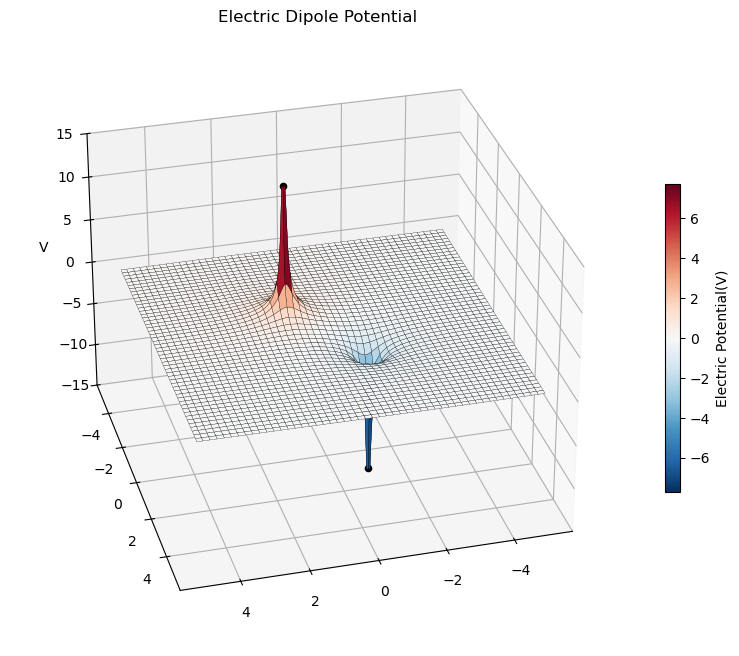

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits import mplot3d
fig=plt.figure(figsize=(10,8))
ax=plt.axes(projection="3d")

class Potential:
    particles=[]
    k=1.0
    x0=0
    y0=0
    def __init__(self,x,y,q):
        self.q=q
        self.x=x
        self.y=y
        Potential.particles.append(self)

    def calculate_V(self,X,Y):
        dist=np.sqrt((X-self.x)**2+(Y-self.y)**2)

        return self.k*self.q/dist

x=np.linspace(-5,5,300)
y=np.linspace(-5,5,300)
X,Y=np.meshgrid(x,y)
Z=np.zeros(X.shape)

p1=Potential(x=1,y=-1,q=1)
p2=Potential(x=-1,y=1,q=-1)

with np.errstate(divide="ignore",invalid="ignore"):
    for i in Potential.particles:
        Z+=i.calculate_V(X,Y)
    
limit=15
Z[(Z>limit)]=limit
Z[(Z<-limit)]=-limit
surf=ax.plot_surface(X,Y,Z,lw=0.2,cmap="RdBu_r",edgecolor="black")

for p in Potential.particles:
    color="red" if p.q>0 else "blue"
    z_height=limit if p.q>0 else -limit
    ax.scatter3D(p.x,p.y,z_height,c="black")

ax.set_title("Electric Dipole Potential")
ax.set_zlim(-limit,limit)
ax.set_zlabel("V")
fig.colorbar(surf,shrink=0.5,label="Electric Potential(V)")
ax.view_init(30,75)
plt.savefig("Dipole_Potential",dpi=300)
plt.show()